# Multi-factor Strategies Coding Challenge - Spring 2025

In [1]:
"""

Your Name: Joshua Hizgiaev

"""

'\n\nYour Name: Joshua Hizgiaev\n\n'

The Multi-factor teams are dedicated to calculating predicted expected returns of securities and sectors. We research and implement multi-factor models with the goal of calculating the expected forward-looking returns.

**Rules:**


*   You are absolutely allowed to use LLMs, but you MUST cite any use with a comment on each line written by it.
*   Any code not written by you must be cited similarly.
*   No machine learning is allowed for this challenge.

**Hints:**


*   Read all of the instructions carefully!
*   Comment your code with as much detail as you can. The easier it is for us to follow, the better!
*   Above everything else, we are looking to see that you can think creatively, and justify your thought process.
*   Don't give up if you get stuck! It's better to submit something that's the best that you can do, instead of quitting and not submitting anything.


If you have any questions about this part of the challenge, email Jason Bhalla, the Head of Multifactor Security-Specific Strategies, at jbhalla@stevens.edu.

# Part 0: Data

In the following cell, import any libraries you need.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In the following cell, write your code to load and preprocess the data given to you for the challenge. All data collection should be done here. (Note: You are allowed to import additional data if you wish.

In [3]:
df = pd.ExcelFile('./multifactor_security_data.xlsx')
sheets = df.sheet_names
sheets

['Stock Price',
 'Historical Market Cap',
 'Book Value per Share',
 'Total Equity',
 'Total Assets',
 'PE Ratio',
 'Operating Income',
 'Market (S&P 500) Price',
 '10-Year Treasury']

In [4]:
def fix_dataset(sheet_name: str, source: pd.ExcelFile, rows_to_skip: int = 67) -> pd.DataFrame:
    data = pd.read_excel(source, sheet_name=sheet_name)
    data = data.iloc[rows_to_skip:]
    # make sure date is of proper type
    data = data.rename(columns={'Start Date':'Date',pd.Timestamp('2005-02-07 00:00:00'): 'AAPL', 'Unnamed: 2': 'NVDA', 'Unnamed: 3': 'JPM', 'Unnamed: 4': 'GS'})
    data['Date'] = pd.to_datetime(data['Date'])
    # make sure the rest of the columns are proper type
    for col in data.columns:
        if col == 'Date': continue
        data[col] = pd.to_numeric(data[col], errors='raise', downcast='float')
    data = data.reset_index(drop=True)
    return data

stock_prices = fix_dataset('Stock Price', df)
market_cap = fix_dataset('Historical Market Cap', df)
book_value = fix_dataset('Book Value per Share', df)
total_equity = fix_dataset('Total Equity', df)
total_assets = fix_dataset('Total Assets', df)
pe_ratio = fix_dataset('PE Ratio', df)
operating_income = fix_dataset('Operating Income', df)

# Manually dealing with SPY and Treasury
sp500 = pd.read_excel(df, sheet_name='Market (S&P 500) Price')
sp500 = sp500.iloc[8:]
sp500 = sp500.rename(columns={'Start Date':'Date',pd.Timestamp('2005-02-07 00:00:00'): 'SPY'})
sp500['Date'] = pd.to_datetime(sp500['Date'])
sp500['SPY'] = pd.to_numeric(sp500['SPY'], errors='raise')
sp500 = sp500.reset_index(drop=True)

treasury = pd.read_excel(df, sheet_name='10-Year Treasury')
treasury = treasury.iloc[8:]
treasury = treasury.rename(columns={'Start Date':'Date',pd.Timestamp('2005-02-08 00:00:00'): '10YR'})
treasury['Date'] = pd.to_datetime(treasury['Date'])
treasury['10YR'] = pd.to_numeric(treasury['10YR'], errors='raise')
treasury = treasury.reset_index(drop=True)

In [5]:
print(stock_prices.shape)
print(market_cap.shape)
print(book_value.shape)
print(total_equity.shape)
print(total_assets.shape)
print(pe_ratio.shape)
print(operating_income.shape)
print(sp500.shape)

(5158, 5)
(5158, 5)
(5158, 5)
(5158, 5)
(5158, 5)
(5158, 5)
(5158, 5)
(5031, 2)


In the following cell, write any comments about your code and reasoning, such as why you processed the data in a certain way, what you noticed, where you found any additional data (if you decide to do so), etc.

In [6]:
"""

When initially examining the datasheets in Microsoft Excel, I noticed the 
first 10 sheets were poorly formatted and most were filled with NaN's for
the first 66 rows of the data. 

I decided to simply cut the first 66 rows from each of the first 7 datasets as 
the data loss from doing so is very minimal and wont have great effect on the 
proceeding models. In addition, I ensured that each columns were of proper pandas 
datatypes and that the index for each dataframe was properly set to make it easy 
to work with the data later on. I also allow for the number of rows to skip to 
be set so I can get consistent dimensions amongst the assets.

A similar process followed for the S&P dataset and treasury datasets, but less
rows were cut.

"""

"\n\nWhen initially examining the datasheets in Microsoft Excel, I noticed the \nfirst 10 sheets were poorly formatted and most were filled with NaN's for\nthe first 66 rows of the data. \n\nI decided to simply cut the first 66 rows from each of the first 7 datasets as \nthe data loss from doing so is very minimal and wont have great effect on the \nproceeding models. In addition, I ensured that each columns were of proper pandas \ndatatypes and that the index for each dataframe was properly set to make it easy \nto work with the data later on. I also allow for the number of rows to skip to \nbe set so I can get consistent dimensions amongst the assets.\n\nA similar process followed for the S&P dataset and treasury datasets, but less\nrows were cut.\n\n"

# Part 1: Capital Asset Pricing Model (CAPM)

The Capital Asset Pricing Model (CAPM) is a popular model that describes the relationship between the expected return and the risk of investing in a security.

In the following cell, implement the Capital Asset Pricing Model on the data given to you for Part 1.

Your final result should be the expected forward-looking returns for the assets given in the data.

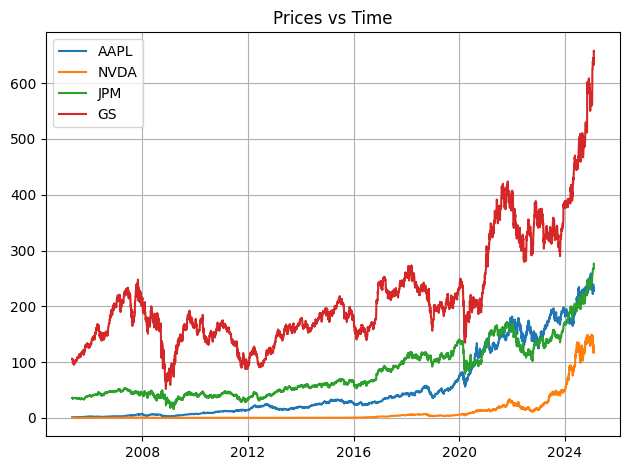

In [7]:
# Visualize data
def plot_graph(df: pd.DataFrame, title: str) -> None:
    plt.title(title)
    plt.grid(True)
    for i in df.columns[1:]:
        plt.plot(df['Date'],df[i], label=i)
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_graph(stock_prices,title='Prices vs Time')        

In [8]:
# get the daily returns for stocks and SPY
def daily_returns(df: pd.DataFrame) -> pd.DataFrame:
    df_daily_returns = df.copy()
    for i in df.columns:
        if i != 'Date':
            for j in range(1,len(df)):
                df_daily_returns.loc[j, i] = ((df.loc[j, i] - df.loc[j-1, i])/df.loc[j-1, i]) * 100
            df_daily_returns.loc[0, i]=0
    return df_daily_returns

# I decided to merge the stock prices and the S&P on date, this ensures
# all data is properly associated with a date and each stock price is associated
# with the market to give the most accurate results, but does lead in the loss
# of a couple hundred rows of data, still acceptable under circumstances 

merged_sp_stocks = pd.merge(stock_prices, sp500, on='Date', how='inner')
stocks_daily_return = daily_returns(merged_sp_stocks)
stocks_daily_return

,Date,AAPL,NVDA,JPM,GS,SPY
0,2005-05-04,0.000000,0.000000,0.000000,0.000000,0.000000
1,2005-05-05,-1.281091,1.980730,-0.554008,-0.912763,-0.034043
2,2005-05-06,1.526725,1.364829,-0.807802,-0.588796,-0.315001
3,2005-05-09,-0.751879,1.864320,0.982866,0.783339,0.623452
4,2005-05-10,-1.439398,-3.914596,-2.280311,-3.213270,-1.035478
...,...,...,...,...,...,...
4969,2025-02-03,-3.385596,-2.840007,-0.183311,-1.253908,-0.672959
4970,2025-02-04,2.100789,1.705810,0.423524,0.286224,0.670827
4971,2025-02-05,-0.141753,5.208597,0.929309,1.777101,0.405464
4972,2025-02-06,0.322622,3.084187,2.392487,1.978458,0.347556


In [9]:
# get collection of alphas and betas
beta, alpha = {}, {}
for i in stocks_daily_return.columns:
    if i != 'Date' and i != 'SPY':
        b, a = np.polyfit(stocks_daily_return['SPY'], stocks_daily_return[i], 1)
        beta[i] = b
        alpha[i] = a

In [10]:
expected_returns = {}
keys = list(beta.keys())
rf = treasury.iloc[-1]['10YR']/100 # using the most recent risk free rate return
rm = stocks_daily_return['SPY'].mean() * 252
for i in keys:
    expected_returns[i] = alpha[i] + (beta[i] * (rm-rf))
for i in keys:
    print(f'Expected forward return based on CAPM for {i} is {expected_returns[i]}')

Expected forward return based on CAPM for AAPL is 10.745889682958532
Expected forward return based on CAPM for NVDA is 15.707348627424786
Expected forward return based on CAPM for JPM is 13.734692542908375
Expected forward return based on CAPM for GS is 13.39278963567146


In the following cell, write any comments about your code and reasoning, such as why you implemented the CAPM in a specific way, what you noticed, what the significance of this is, etc.

In [11]:
"""

For the CAPM section of this challenge, I needed to calculate the expected
forward looking returns for the assets AAPL, NVDA, JPM, and GS. The formula I
used for doing so is rho^{fwd} = alpha + beta * (r_m - r_f) where alpha is the
stock specific excess return, beta is the sensitivity of the stock to the market,
r_m is market return (S&P daily return) and r_f is risk free rate (10-year treasury
yield).

I begin by caclulating the daily returns of each stock and the S&P with a simple
for loop. Then, I calculate all the alphas and betas for each stock using numpy's
polynomial fit function (with the degree 1 so it is linear). What this does is fit
the line between each individual stock and the market to get the line of best fit.

Finally, I do the forward expected return calculation for each stock by doing
rho^{fwd} = alpha + beta * (r_m - r_f), the risk free rate I chose to be the
most recent 10-year treasury yield and r_m is simply the mean of the S&P * 252
(252 trading days in a year).

In other versions of CAPM however, instead of alpha, r_f is used, the results for 
that are given below (very minimal difference):

Expected forward return based on CAPM for AAPL is 10.709667995250793
Expected forward return based on CAPM for NVDA is 15.635324960355037
Expected forward return based on CAPM for JPM is 13.767172598655709
Expected forward return based on CAPM for GS is 13.430244731473588

"""

"\n\nFor the CAPM section of this challenge, I needed to calculate the expected\nforward looking returns for the assets AAPL, NVDA, JPM, and GS. The formula I\nused for doing so is rho^{fwd} = alpha + beta * (r_m - r_f) where alpha is the\nstock specific excess return, beta is the sensitivity of the stock to the market,\nr_m is market return (S&P daily return) and r_f is risk free rate (10-year treasury\nyield).\n\nI begin by caclulating the daily returns of each stock and the S&P with a simple\nfor loop. Then, I calculate all the alphas and betas for each stock using numpy's\npolynomial fit function (with the degree 1 so it is linear). What this does is fit\nthe line between each individual stock and the market to get the line of best fit.\n\nFinally, I do the forward expected return calculation for each stock by doing\nrho^{fwd} = alpha + beta * (r_m - r_f), the risk free rate I chose to be the\nmost recent 10-year treasury yield and r_m is simply the mean of the S&P * 252\n(252 trad

# Part 2: Multi-factor Model

The objective of this is to create a multifactor model based on the provided data. The model can be an existing model that you research and implement, or you can use the data to create a new multifactor model of your choice. The only restriction is that your model must include a minimum of 3 factors.

Be creative!

Your model does not necessarily need to perform well. We are mainly looking to see your creativity and whether you can express your thought process.

You are free to pull any additional data, or you can stick with the financial data given to you for this part.

In the following cell, implement your three-factor model.

Your final result should be the expected forward-looking returns for the 4 stocks.

In [12]:
from sklearn.linear_model import LinearRegression

# Implementing Fama-French 3 Factor Model!
daily_returns_ff = daily_returns(merged_sp_stocks)

# Market Risk Premium (MRP)
mrp = daily_returns_ff['SPY'] - rf / 252

# SMB (Small Minus Big) - Size factor
median_market_cap = market_cap.iloc[:, 1:].median(axis=1)
small_caps = market_cap.iloc[:, 1:].lt(median_market_cap, axis=0)
big_caps = market_cap.iloc[:, 1:].ge(median_market_cap, axis=0)

smb = daily_returns_ff.loc[:, small_caps.columns].where(small_caps).mean(axis=1) - daily_returns_ff.loc[:, big_caps.columns].where(big_caps).mean(axis=1)

# HML (High Minus Low) - Value factor
book_to_market = total_equity.iloc[:, 1:] / market_cap.iloc[:, 1:]
median_btm = book_to_market.median(axis=1)
high_btm = book_to_market.ge(median_btm, axis=0)
low_btm = book_to_market.lt(median_btm, axis=0)

hml = daily_returns_ff.loc[:, high_btm.columns].where(high_btm).mean(axis=1) - daily_returns_ff.loc[:, low_btm.columns].where(low_btm).mean(axis=1)

beta_ff, alpha_ff = {}, {}

# Pretty similar to CAPM process
for stock in stock_prices.columns:
    if stock not in ['Date', 'SPY']:
        X = pd.DataFrame({'MRP': mrp,'SMB': smb,'HML': hml}).dropna()
        y = daily_returns_ff[stock].loc[X.index]
        model = LinearRegression().fit(X, y)
        beta_ff[stock] = model.coef_
        alpha_ff[stock] = model.intercept_

expected_returns_ff = {}
avg_mrp = mrp.mean() * 252
avg_smb = smb.mean() * 252
avg_hml = hml.mean() * 252
for stock in beta_ff.keys():
    betas = beta_ff[stock]
    expected_returns_ff[stock] = rf + betas[0] * avg_mrp + betas[1] * avg_smb + betas[2] * avg_hml + alpha_ff[stock]

for i in expected_returns_ff:
    print(f'Expected forward return based on Fama-French 3-Factor Model for {i} is {expected_returns_ff[i]}')

Expected forward return based on Fama-French 3-Factor Model for AAPL is 18.89878349663995
Expected forward return based on Fama-French 3-Factor Model for NVDA is 31.797971757039324
Expected forward return based on Fama-French 3-Factor Model for JPM is 3.107383962950031
Expected forward return based on Fama-French 3-Factor Model for GS is 3.543579744058954


In the following cell, write any comments about your code and reasoning, such as what your factors were, how you decided on them, what your thought process was, what worked and didn't work, etc. Justify your model as best as you can.

In [13]:
"""

Factor 1: Market Risk Premium (MRP)
Factor 2: SMB (Small Minus Big) - Size factor
Factor 3: HML (High Minus Low) - Value factor
Other Factors: N/A

I decided to do Fama-French 3-Factor Model for ease of implementation and its popular use in the 
markets while researching multifactor models. The factors used were Market Risk Premium (MRP), 
Small Minus Big (SMB), and High Minus Low (HML). These factors were chosen because they capture 
key drivers of stock returns beyond overall market movements. MRP reflects the excess return of 
the market over the risk-free rate, capturing general market risk. SMB accounts for the size effect,
where smaller companies tend to outperform larger ones over time, using market capitalization data. 
HML captures the value effect, reflecting the historical outperformance of value stocks (high book-to-market ratio) 
over growth stocks (low book-to-market ratio) using total equity data. 

The thought process behind choosing these factors is rooted in both how Fama-French works and also 
capturing different dimensions of risk and return that influence stock performance (hopefully) more comprehensively 
than CAPM.

"""

'\n\nFactor 1: Market Risk Premium (MRP)\nFactor 2: SMB (Small Minus Big) - Size factor\nFactor 3: HML (High Minus Low) - Value factor\nOther Factors: N/A\n\nI decided to do Fama-French 3-Factor Model for ease of implementation and its popular use in the \nmarkets while researching multifactor models. The factors used were Market Risk Premium (MRP), \nSmall Minus Big (SMB), and High Minus Low (HML). These factors were chosen because they capture \nkey drivers of stock returns beyond overall market movements. MRP reflects the excess return of \nthe market over the risk-free rate, capturing general market risk. SMB accounts for the size effect,\nwhere smaller companies tend to outperform larger ones over time, using market capitalization data. \nHML captures the value effect, reflecting the historical outperformance of value stocks (high book-to-market ratio) \nover growth stocks (low book-to-market ratio) using total equity data. \n\nThe thought process behind choosing these factors is 

# Part 3: Backtesting

A very important part of the model-building process is backtesting. Backtesting is where you compare your model's performance against a benchmark to see how well it performs. In this section, you will backtest your expected forward-looking returns from your multifactor model against the actual forward-looking returns for each stock.

In the following cell, backtest your CAPM model against actual returns for the stocks. In addition to plotting the returns, provide the Sharpe Ratio, Cumulative Returns, and Volatility against the S&P 500.

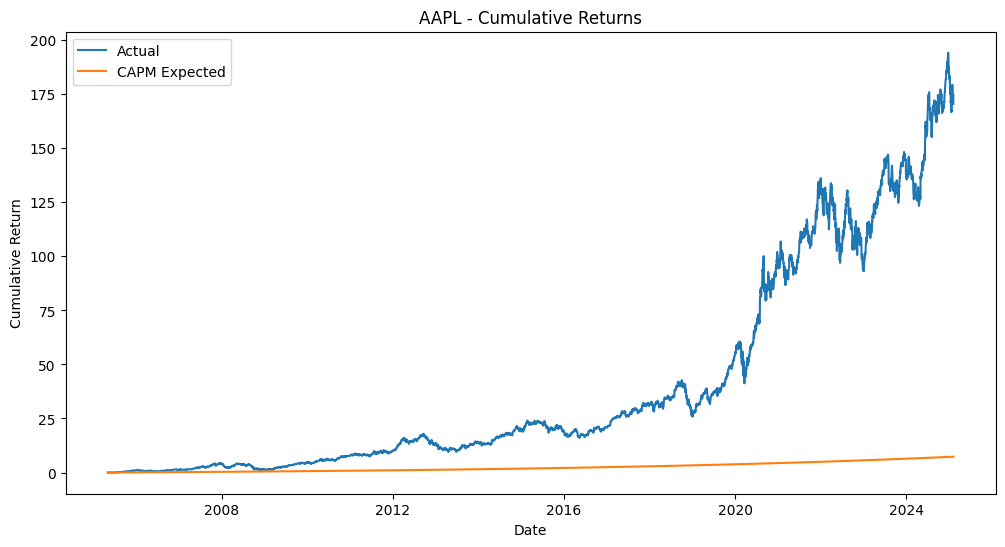

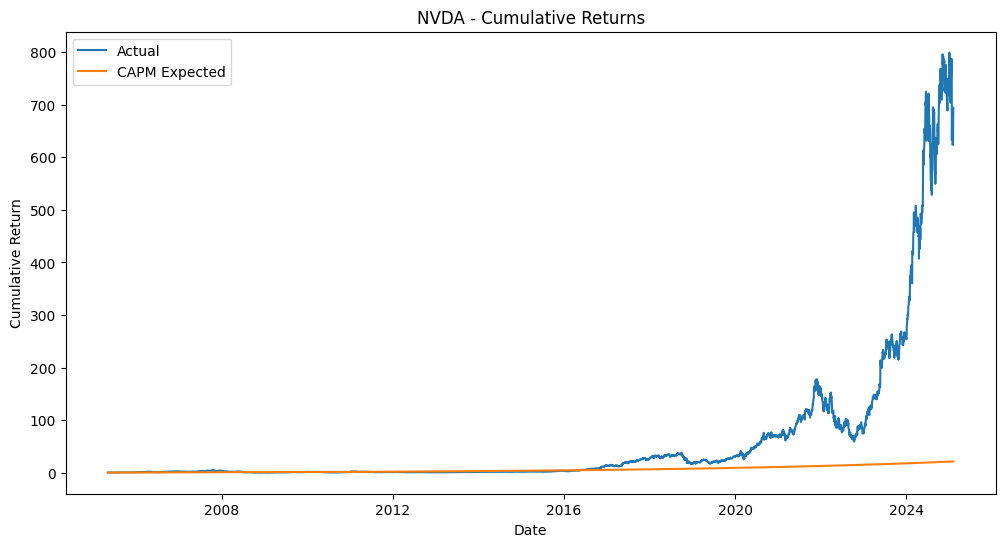

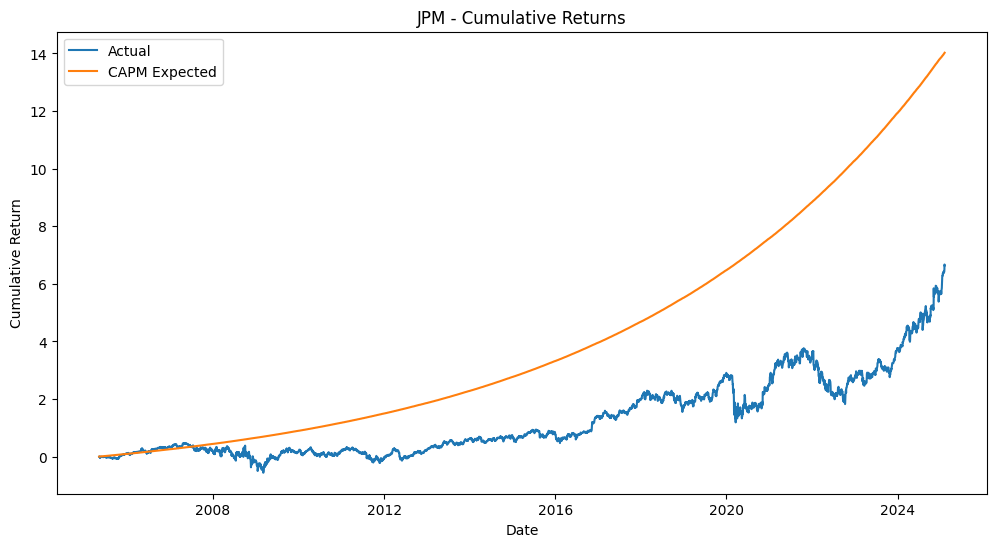

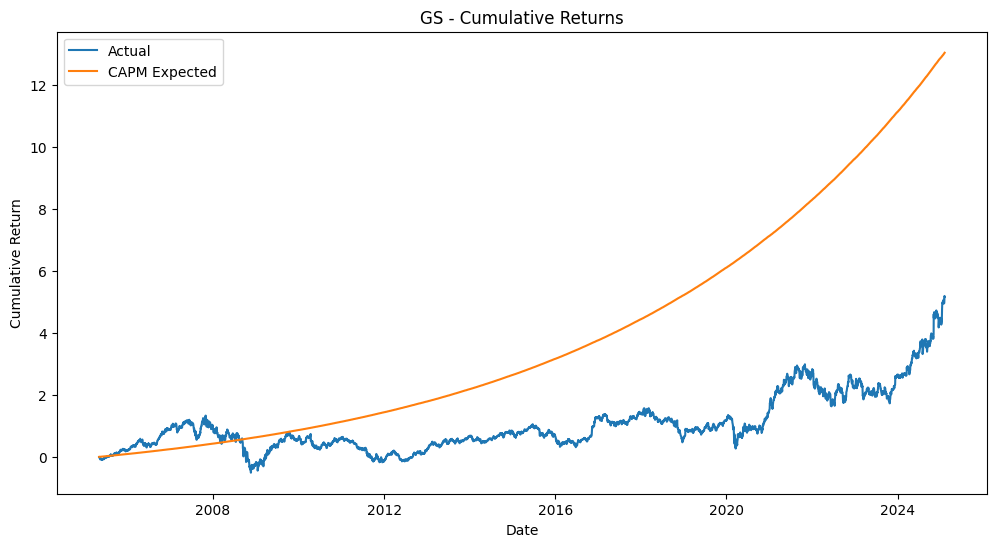

AAPL:
  Sharpe Ratio: 0.9758814291456747
  Cumulative Return for CAPM: 170.53770446777344 | Cumulative Return for CAPM (Expected): 7.3359862724367915
  Volatility: 31.897897529597657 (vs SPY: 19.147243563784144)

NVDA:
  Sharpe Ratio: 0.9220046467780851
  Cumulative Return for CAPM: 694.0748901367188 | Cumulative Return for CAPM (Expected): 21.183873431136995
  Volatility: 48.91630901110734 (vs SPY: 19.147243563784144)

JPM:
  Sharpe Ratio: 0.46162021790235885
  Cumulative Return for CAPM: 6.639919757843018 | Cumulative Return for CAPM (Expected): 14.032705397929636
  Volatility: 36.57509163634598 (vs SPY: 19.147243563784144)

GS:
  Sharpe Ratio: 0.4356650409769166
  Cumulative Return for CAPM: 5.172025203704834 | Cumulative Return for CAPM (Expected): 13.052205659168086
  Volatility: 35.098460652022695 (vs SPY: 19.147243563784144)



In [14]:
# Get some basic metric functions
def forward_returns(df: pd.DataFrame, period: int = 1) -> pd.DataFrame:
    df_forward = df.copy()
    for col in df.columns:
        if col != 'Date':
            df_forward[col] = df[col].shift(-period)
    return df_forward

def sharpe_ratio(returns, risk_free_rate):
    excess_returns = returns - risk_free_rate / 252
    return np.mean(excess_returns) / np.std(excess_returns) * np.sqrt(252)

def cumulative_returns(returns):
    return (1 + returns / 100).cumprod() - 1

def annualized_volatility(returns):
    return np.std(returns) * np.sqrt(252)

# Forward returns for next-day performance
actual_forward_returns = forward_returns(stocks_daily_return)

backtest_results = pd.DataFrame({'Date': stocks_daily_return['Date']})
for stock in expected_returns.keys():
    backtest_results[stock + '_expected'] = expected_returns[stock] / 252  # Convert to daily returns
    backtest_results[stock + '_actual'] = actual_forward_returns[stock]

metrics = {}
for stock in expected_returns.keys(): # Get the metrics for each stock individually
    actual_returns = backtest_results[stock + '_actual'].dropna()
    expected_returns = backtest_results[stock + '_expected'].dropna()
    
    c_returns_exp = cumulative_returns(expected_returns) # Grab cummulative returns for expected as well
    
    c_returns_actual = cumulative_returns(actual_returns)
    sharpe_actual = sharpe_ratio(actual_returns, rf)
    vol_actual = annualized_volatility(actual_returns)
    
    metrics[stock] = {
        'Sharpe Ratio': sharpe_actual,
        'Cumulative Return': (c_returns_actual.iloc[-1],c_returns_exp.iloc[-1]),
        'Volatility': vol_actual
    }

    plt.figure(figsize=(12, 6))
    plt.plot(backtest_results['Date'][:len(c_returns_actual)], c_returns_actual, label='Actual')
    plt.plot(backtest_results['Date'][:len(c_returns_actual)], cumulative_returns(backtest_results[stock + '_expected'].iloc[:len(c_returns_actual)]), label='CAPM Expected')
    plt.title(f'{stock} - Cumulative Returns')
    plt.xlabel('Date')
    plt.ylabel('Cumulative Return')
    plt.legend()
    plt.show()

sp500_vol = annualized_volatility(stocks_daily_return['SPY'])
for stock, stats in metrics.items():
    print(f"{stock}:")
    print(f"  Sharpe Ratio: {stats['Sharpe Ratio']}")
    print(f"  Cumulative Return for CAPM: {stats['Cumulative Return'][0]} | Cumulative Return for CAPM (Expected): {stats['Cumulative Return'][1]}")
    print(f"  Volatility: {stats['Volatility']} (vs SPY: {sp500_vol})\n")

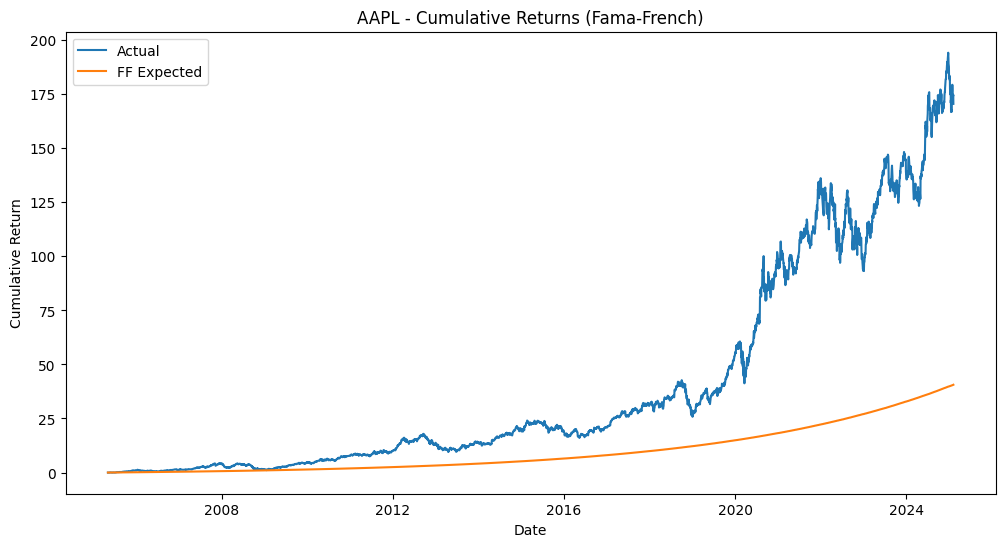

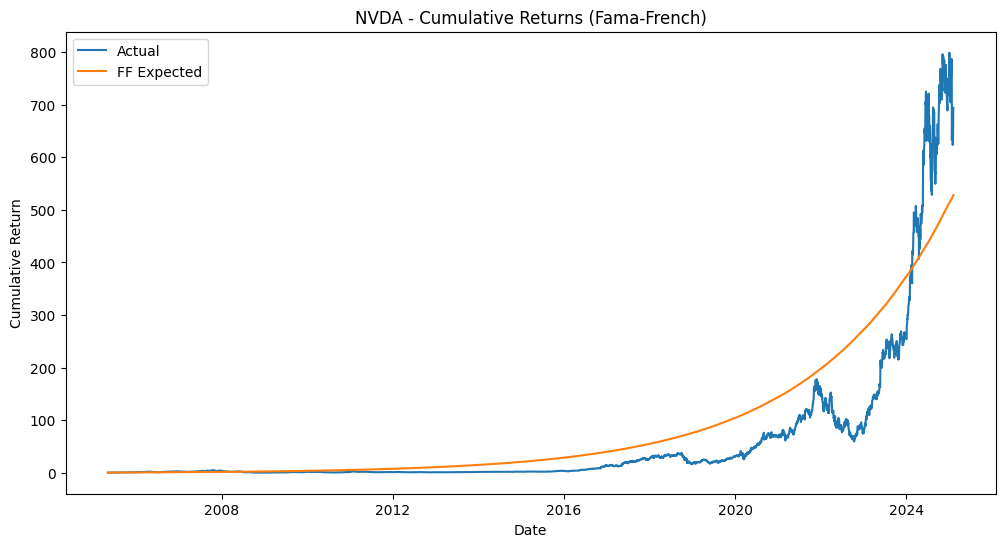

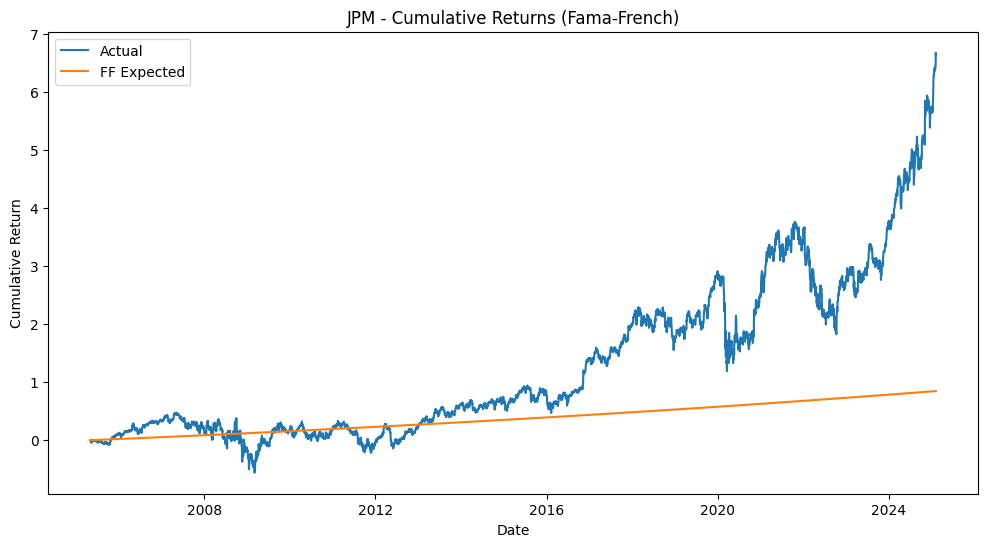

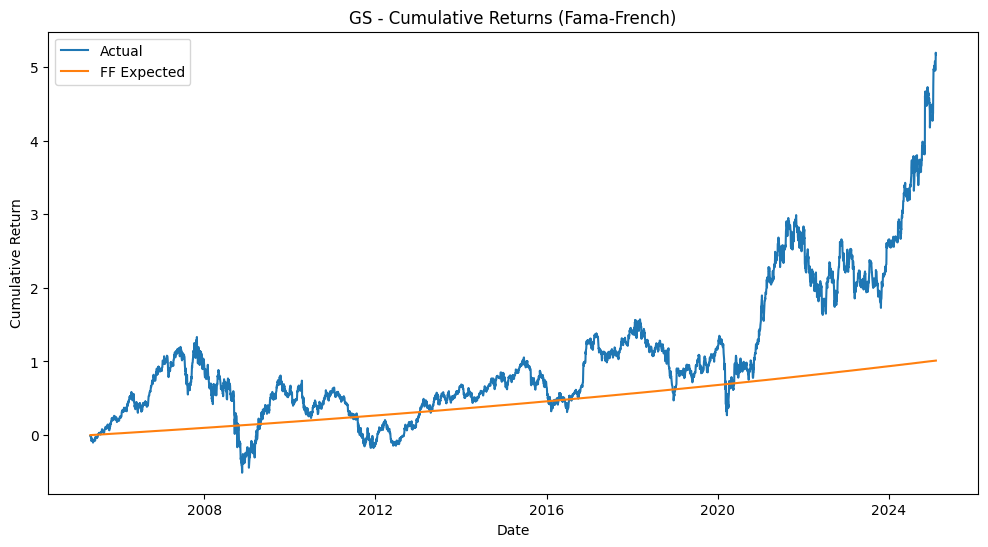

AAPL:
  Sharpe Ratio: 0.9758814291456747
  Cumulative Return: 170.53770446777344 | Cumulative Return (Expected): 40.63169711161047
  Volatility: 31.897897529597657 (vs SPY: 19.147243563784144)

NVDA:
  Sharpe Ratio: 0.9220046467780851
  Cumulative Return: 694.0748901367188 | Cumulative Return (Expected): 528.7247194957195
  Volatility: 48.91630901110734 (vs SPY: 19.147243563784144)

JPM:
  Sharpe Ratio: 0.46162021790235885
  Cumulative Return: 6.639919757843018 | Cumulative Return (Expected): 0.8465159515759559
  Volatility: 36.57509163634598 (vs SPY: 19.147243563784144)

GS:
  Sharpe Ratio: 0.4356650409769166
  Cumulative Return: 5.172025203704834 | Cumulative Return (Expected): 1.01251658779535
  Volatility: 35.098460652022695 (vs SPY: 19.147243563784144)



In [15]:
# Back test for Fama-French, just a copy and past of my previous backtest (can be functionalized for generalization)
actual_forward_returns_ff = forward_returns(daily_returns_ff)

backtest_results_ff = pd.DataFrame({'Date': daily_returns_ff['Date']})
for stock in expected_returns_ff.keys():
    backtest_results_ff[stock + '_expected'] = expected_returns_ff[stock] / 252  # Convert to daily returns
    backtest_results_ff[stock + '_actual'] = actual_forward_returns_ff[stock]
metrics_ff = {}

for stock in expected_returns_ff.keys():
    actual_returns = backtest_results_ff[stock + '_actual'].dropna()
    expected_returns = backtest_results_ff[stock + '_expected'].dropna()
    
    c_returns_exp = cumulative_returns(expected_returns)
    
    c_returns = cumulative_returns(actual_returns)
    sharpe = sharpe_ratio(actual_returns, rf)
    vol = annualized_volatility(actual_returns)
    metrics_ff[stock] = {
        'Sharpe Ratio': sharpe,
        'Cumulative Return': (c_returns.iloc[-1], c_returns_exp.iloc[-1]),
        'Volatility': vol
    }

    plt.figure(figsize=(12, 6))
    plt.plot(backtest_results_ff['Date'][:len(c_returns)], c_returns, label='Actual')
    plt.plot(backtest_results_ff['Date'][:len(c_returns)], cumulative_returns(backtest_results_ff[stock + '_expected'].iloc[:len(c_returns)]), label='FF Expected')
    plt.title(f'{stock} - Cumulative Returns (Fama-French)')
    plt.xlabel('Date')
    plt.ylabel('Cumulative Return')
    plt.legend()
    plt.show()

sp500_vol_ff = annualized_volatility(daily_returns_ff['SPY'])
for stock, stats in metrics_ff.items():
    print(f"{stock}:")
    print(f"  Sharpe Ratio: {stats['Sharpe Ratio']}")
    print(f"  Cumulative Return: {stats['Cumulative Return'][0]} | Cumulative Return (Expected): {stats['Cumulative Return'][1]}")
    print(f"  Volatility: {stats['Volatility']} (vs SPY: {sp500_vol_ff})\n")

In the following cell, write any comments about your code and reasoning, such as what the takeaways are from the backtesting, what you noticed about the results, what they tell you, what you would do differently next time, etc.

In [16]:
"""

I see that Fama-French is far more accurate than CAPM after initial viewing. This leads me to believe that with a 
greater amount of factors, and further refinement of the current model, it can be even more accurate, it also 
shows the strength of multifactoring compared to single factor models.

First, daily returns are computed for the stocks and the S&P 500. For CAPM, expected returns are calculated using 
stock betas, alphas, the market risk premium, and the risk-free rate. In the Fama-French model, expected returns 
are derived from the market risk premium (MRP), size (SMB), and value (HML) factors. The backtests then track how 
well the expected returns align with actual performance by calculating metrics such as the Sharpe Ratio, Cumulative
Returns, and Volatility. Finally, these metrics are compared against the S&P 500 benchmark, and cumulative return 
plots visualize the models accuracy over time.

"""

'\n\nI see that Fama-French is far more accurate than CAPM after initial viewing. This leads me to believe that with a \ngreater amount of factors, and further refinement of the current model, it can be even more accurate, it also \nshows the strength of multifactoring compared to single factor models.\n\nFirst, daily returns are computed for the stocks and the S&P 500. For CAPM, expected returns are calculated using \nstock betas, alphas, the market risk premium, and the risk-free rate. In the Fama-French model, expected returns \nare derived from the market risk premium (MRP), size (SMB), and value (HML) factors. The backtests then track how \nwell the expected returns align with actual performance by calculating metrics such as the Sharpe Ratio, Cumulative\nReturns, and Volatility. Finally, these metrics are compared against the S&P 500 benchmark, and cumulative return \nplots visualize the models accuracy over time.\n\n'

# Part 4: Comparison

In the following cell, compare the CAPM model with your multi-factor model. What performed better? Why do you think that is?

In [17]:
"""

CAPM is generally an ok model to use for factor modeling, and yielded
ok (not the best) results. GS gave the worst results compared to the rest of the stocks 
having the lowest metric in all 3 categories when using CAPM. Similar with NVDA,
where the metrics were not close to being accurate at all. With my Fama-French model, 
the assets generally performed very well against it yeilding cummulative returns for
only 3 factors. 

I would say that the Fama-French model performed better by far. It was simply more consistent 
and provided better backtest results all around compared to my CAPM implementation. In addition,
it utilized more factors that allow it to be a lot more accurate than CAPM.

"""

'\n\nCAPM is generally an ok model to use for factor modeling, and yielded\nok (not the best) results. GS gave the worst results compared to the rest of the stocks \nhaving the lowest metric in all 3 categories when using CAPM. Similar with NVDA,\nwhere the metrics were not close to being accurate at all. With my Fama-French model, \nthe assets generally performed very well against it yeilding cummulative returns for\nonly 3 factors. \n\nI would say that the Fama-French model performed better by far. It was simply more consistent \nand provided better backtest results all around compared to my CAPM implementation. In addition,\nit utilized more factors that allow it to be a lot more accurate than CAPM.\n\n'

# References, Reflection, and Submission

In the following cell, list any references and resources you used to help you with this coding challenge (including ChatGPT), and what you got out of each resource. There's nothing wrong with getting help, but it's important to cite when you do!

In [18]:
"""

Learning what CAPM is and implementing: https://blog.mlq.ai/capital-asset-pricing-model-python/
CAPM Concept: https://www.investopedia.com/terms/c/capm.asp#:~:text=The%20capital%20asset%20pricing%20model%20(CAPM)%20describes%20the%20relationship%20between,on%20an%20investment%20and%20risk.
What the Fama-French Model is: https://www.investopedia.com/terms/f/famaandfrenchthreefactormodel.asp
Example of Fama-French in Python: https://sec-api.io/resources/fama-french-factor-model
Another example of Fama-French: https://medium.com/the-handbook-of-coding-in-finance/estimating-stock-returns-with-fama-french-three-factor-model-in-python-1a98e3936859

"""

'\n\nLearning what CAPM is and implementing: https://blog.mlq.ai/capital-asset-pricing-model-python/\nCAPM Concept: https://www.investopedia.com/terms/c/capm.asp#:~:text=The%20capital%20asset%20pricing%20model%20(CAPM)%20describes%20the%20relationship%20between,on%20an%20investment%20and%20risk.\nWhat the Fama-French Model is: https://www.investopedia.com/terms/f/famaandfrenchthreefactormodel.asp\nExample of Fama-French in Python: https://sec-api.io/resources/fama-french-factor-model\nAnother example of Fama-French: https://medium.com/the-handbook-of-coding-in-finance/estimating-stock-returns-with-fama-french-three-factor-model-in-python-1a98e3936859\n\n'

In the following cell, write a brief reflection on what you learned from this challenge. What did you do well? What do you wish you had done differently? Is there anything else you would like to add about your code or process that would help us understand?

In [19]:
"""

I learned that the concept of a factor model itself is very simple, but I would like 
to practice this on my own time because the challenge itself was quite fun. I believe 
I did really well on Fama-French, and that I can do much better on CAPM if I was afforded my time. 
But I think my implementation is solid.

I liked learning the concept of factor models and its purpose. On the outside it
seemed daunting but the mathematics behind it are somewhat trivial (at least from
what I have seen due to the requirements of this challenge). It's an interesting
way of calculating returns and I'm highly interested in applying neural networks
and a weighting vector on factors to create a very complex but hopefully high-
performing model.

Unfortunately, I am under the constraint of time, and I wished I had more time
improving the multifactor model, I wanted to see how much I can improve
Fama-French, in addition, verify the correctness of my implementation.

In addition, it was difficult to find online resources on well known multi-factor 
models besides Fama-French. But overall this challenge was fun, not easy, but not
impossible by any means.

"""

"\n\nI learned that the concept of a factor model itself is very simple, but I would like \nto practice this on my own time because the challenge itself was quite fun. I believe \nI did really well on Fama-French, and that I can do much better on CAPM if I was afforded my time. \nBut I think my implementation is solid.\n\nI liked learning the concept of factor models and its purpose. On the outside it\nseemed daunting but the mathematics behind it are somewhat trivial (at least from\nwhat I have seen due to the requirements of this challenge). It's an interesting\nway of calculating returns and I'm highly interested in applying neural networks\nand a weighting vector on factors to create a very complex but hopefully high-\nperforming model.\n\nUnfortunately, I am under the constraint of time, and I wished I had more time\nimproving the multifactor model, I wanted to see how much I can improve\nFama-French, in addition, verify the correctness of my implementation.\n\nIn addition, it was

Submit this template file in the format "first_last_mfm.ipynb".

Example: "jason_bhalla_mfm.ipynb"